# Logistic Regression

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

## Step 0: Get Iris data

In [2]:
import pandas as pd
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data',
                 header=None, encoding='utf-8')

n_unique_categories = df[4].nunique()
unique_categories = df[4].unique()
print(f"There are {n_unique_categories} categories: {unique_categories}")

df.tail()

There are 3 categories: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Fitting a dataset with X: (100, 2) and y: (100,)


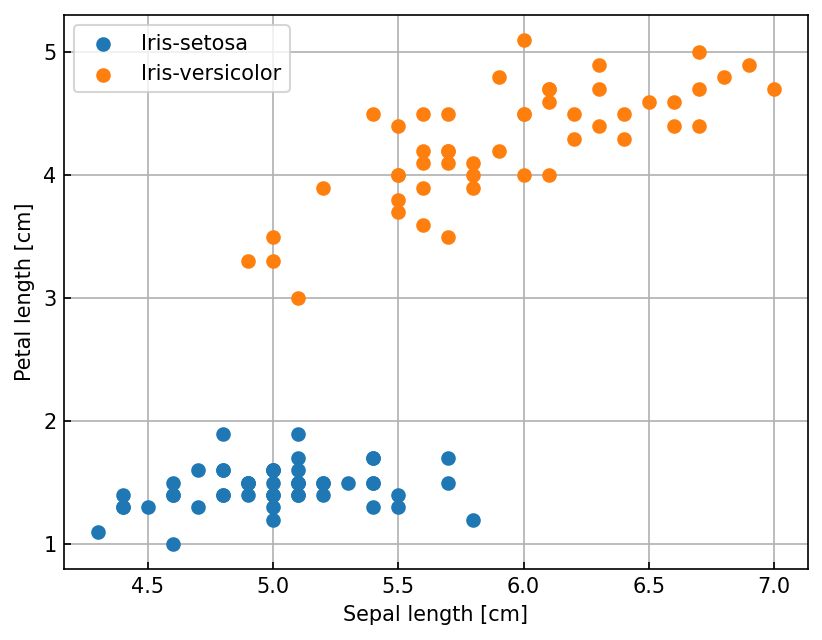

In [3]:
mask = df[4] != 'Iris-virginica'

X = df.loc[mask, [0, 2]].values
y = df.loc[mask, 4].values
print(f"Fitting a dataset with X: {X.shape} and y: {y.shape}")

labels = np.unique(y)
ax = plt.figure().gca()
for label in labels:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=label)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')
ax.legend();

In [4]:
y_enc = np.zeros(y.shape)
y_enc[y == 'Iris-versicolor'] = 1
print(f'There are {int(y_enc.sum())} examples of Iris-versicolor')

There are 50 examples of Iris-versicolor


In [5]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.05, colors=['red', 'blue']):
    """ Helper function for plotting a decision boundary in 2D space
    """
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min() - 10*d, X[:, 0].max() + 10*d, d),
        np.arange(X[:, 1].min() - 10*d, X[:, 1].max() + 10*d, d),
    )
    y_grid = model.predict(np.stack([x1.ravel(), x2.ravel()]).T) # [N, 2]
    y_grid = y_grid.reshape(x1.shape)

    cmap = ListedColormap(colors)
    im = ax.pcolormesh(x1, x2, y_grid, cmap=cmap, alpha=0.5)

    for ii, label in enumerate(np.unique(y)):
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], color=colors[int(label)])
        

## Step 1: Define Logistic Regression base class

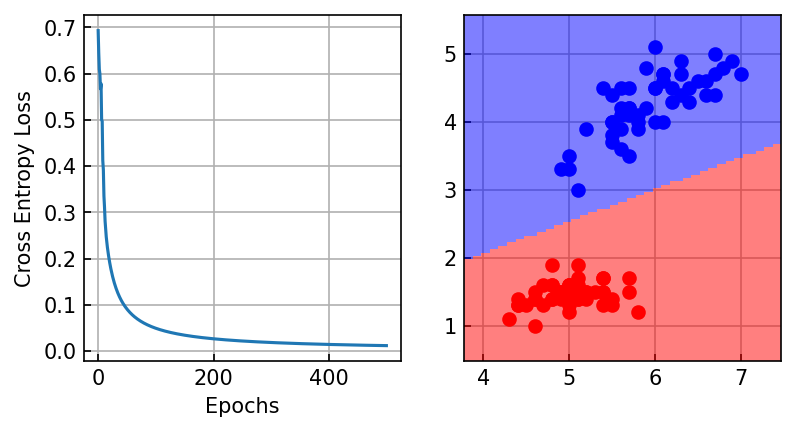

In [6]:
class LogisticRegression:
    def __init__(self,
                 alpha=0.25, 
                 num_epochs=500,
                 random_seed=42):
        self.alpha = alpha
        self.num_epochs = num_epochs
        self.random_seed = random_seed

    def fit(self, X, y):
        """ X : ndarray with shape [n_examples, n_features]
            y : ndarray with shape [n_examples,]
        """
        np.random.seed(self.random_seed)
        self.w_ = np.random.normal(loc=0, scale=0.01, size=X.shape[1])
        self.b_ = np.float32(0.)

        self.loss = []
        
        # iterate over epochs
        for _ in range(self.num_epochs):
             loss = self._fit_epoch(X, y)
             self.loss.append(loss)

        return self

    def _fit_epoch(self, X, y):
        z_pred = self._pre_activation(X)
        y_pred = self._activation(z_pred)
        diff = y - y_pred

        self.w_ += self.alpha * diff.dot(X) / X.shape[0]
        self.b_ += self.alpha * diff.sum() / X.shape[0]

        loss = self._cross_entropy(y, y_pred)
        return loss

    def _cross_entropy(self, y_true, y_pred, eps=1e-10):
        return -np.mean(
            y_true * np.log(y_pred + eps) + \
            (1 - y_true) * np.log(1 - y_pred + eps)
        )

    def _pre_activation(self, X):
        return np.dot(X, self.w_) + self.b_

    def _activation(self, z):
        return 1. / (1 + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):
        z_pred = self._pre_activation(X)
        y_pred = self._activation(z_pred)
        return np.where(y_pred >= 0.5, 1, 0)

lr_model = LogisticRegression(alpha=0.25, num_epochs=500)
lr_model.fit(X, y_enc)

fig, ax = plt.subplots(1, 2, figsize=(6,3))
ax[0].plot(lr_model.loss)
ax[0].set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='linear');
plot_decision_boundary(ax[1], X, y_enc, lr_model)

## Nonlinear model

Despite having a nonlinear activation function, logistic regression still only learns a linear decision boundary. We can learn a nonlinear decision boundary by augmenting the set of features available for decision-making. To do this, we will leverage the `PolynomialFeatures` class from `scikit-learn`. 

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from itertools import product
# PolynomialFeatures? # Uncomment to view the docstring

poly = PolynomialFeatures(degree=2)
names = ['1', 'x1', 'x2', 'x3']
features = [1., 2., 3.]
print(f'Suppose [x1, x2, x3] = {features}')

poly_features = poly.fit_transform(np.array([features])).squeeze()
print('PolynomialFeatures(degree=2) produces', poly_features.shape)
count = 0

for i in range(len(names)):
    for j in range(i, len(names)):
        print(f'{names[i]} * {names[j]} = {poly_features[count]}')
        count += 1

Suppose [x1, x2, x3] = [1.0, 2.0, 3.0]
PolynomialFeatures(degree=2) produces (10,)
1 * 1 = 1.0
1 * x1 = 1.0
1 * x2 = 2.0
1 * x3 = 3.0
x1 * x1 = 1.0
x1 * x2 = 2.0
x1 * x3 = 3.0
x2 * x2 = 4.0
x2 * x3 = 6.0
x3 * x3 = 9.0


Degree 2 augmented feature set contains 5 features


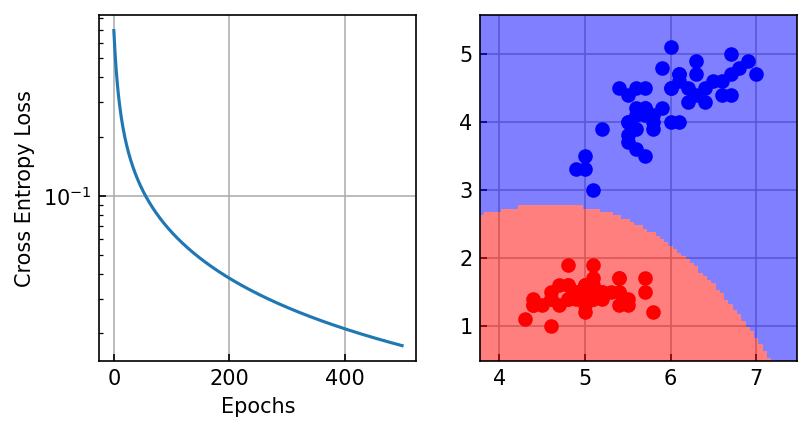

In [8]:
# We often scale features before fitting to stabilize performance
from sklearn.preprocessing import StandardScaler

class LogisticRegressionPolynomial(LogisticRegression):
    def __init__(self, degree=1, **kwargs):
        self.degree = degree
        super().__init__(**kwargs)

    def fit(self, X, y):
        np.random.seed(self.random_seed)
        self.poly_ = PolynomialFeatures(degree=self.degree, include_bias=False)
        self.poly_.fit(X)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X)
        
        print(f'Degree {self.degree} augmented feature set contains {self.poly_.n_output_features_} features')

        self.w_ = np.random.normal(loc=0, scale=0.01, 
                                   size=self.poly_.n_output_features_)
        self.b_ = np.float32(0.)

        self.loss = []
        # iterate over epochs
        for _ in range(self.num_epochs):
             loss = self._fit_epoch(X, y)
             self.loss.append(loss)

        return self

    def _preprocess(self, X):
        X_std = self.scaler_.transform(X)
        return self.poly_.transform(X_std)

    def _fit_epoch(self, X, y):
        X_prep = self._preprocess(X)
        z_pred = self._pre_activation(X_prep)
        y_pred = self._activation(z_pred)
        diff = y - y_pred

        self.w_ += self.alpha * diff.dot(X_prep) / X.shape[0]
        self.b_ += self.alpha * diff.sum() / X.shape[0]

        loss = self._cross_entropy(y, y_pred)
        return loss

    def predict(self, X):
        X_prep = self._preprocess(X)
        return super().predict(X_prep)

lr_model = LogisticRegressionPolynomial(degree=2)
lr_model.fit(X, y_enc)

fig, ax = plt.subplots(1, 2, figsize=(6,3))
ax[0].plot(lr_model.loss)
ax[0].set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='log');
plot_decision_boundary(ax[1], X, y_enc, lr_model)

### What happens if we add more polynomials to the feature library?

Degree 1 augmented feature set contains 2 features
Degree 2 augmented feature set contains 5 features
Degree 3 augmented feature set contains 9 features
Degree 4 augmented feature set contains 14 features
Degree 5 augmented feature set contains 20 features
Degree 10 augmented feature set contains 65 features


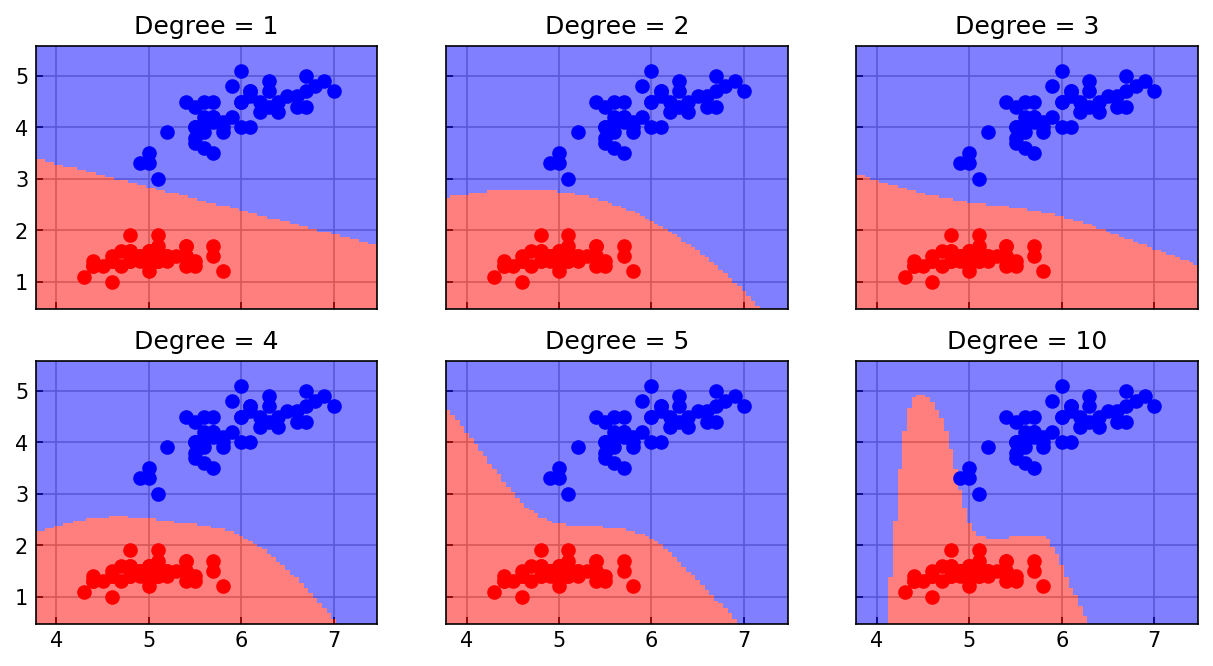

In [9]:
degrees = [1, 2, 3, 4, 5, 10]
ax_db = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 5))[1].flatten()

for ax, degree in zip(ax_db, degrees):
    deg_model = LogisticRegressionPolynomial(degree=degree)
    deg_model.fit(X, y_enc)

    plot_decision_boundary(ax, X, y_enc, deg_model)
    ax.set_title(f'Degree = {degree}')

## Regularization

Degree 10 augmented feature set contains 65 features


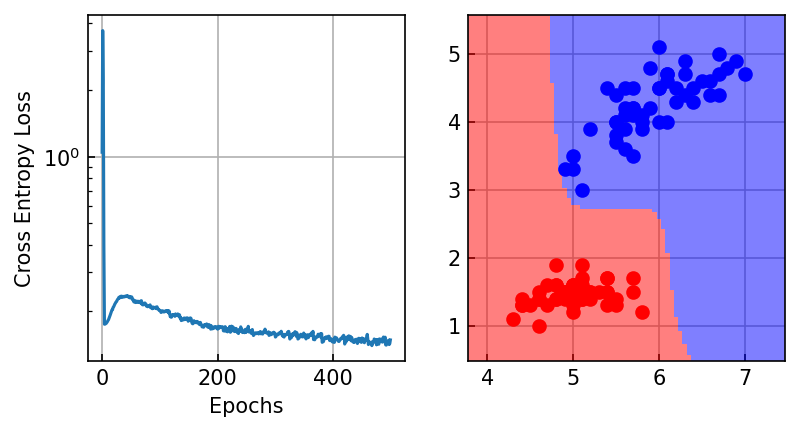

In [10]:
class L1LogisticRegression(LogisticRegressionPolynomial):
    def __init__(self, reg_weight=0.1, **kwargs):
        self.reg_weight = reg_weight
        super().__init__(**kwargs)

    def _fit_epoch(self, X, y):
        X_prep = self._preprocess(X)
        z_pred = self._pre_activation(X_prep)
        y_pred = self._activation(z_pred)
        diff = y - y_pred

        self.w_ += self.alpha * diff.dot(X_prep) / X.shape[0] - \
            self.alpha * self.reg_weight * np.sign(self.w_)
        self.b_ += self.alpha * diff.sum() / X.shape[0]

        loss = self._cross_entropy(y, y_pred)
        return loss

l1_model = L1LogisticRegression(degree=10, reg_weight=0.1)
l1_model.fit(X, y_enc)

fig, ax = plt.subplots(1, 2, figsize=(6,3))
ax[0].plot(l1_model.loss)
ax[0].set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='log');
plot_decision_boundary(ax[1], X, y_enc, l1_model)

Degree 1 augmented feature set contains 2 features
Degree 1 augmented feature set contains 2 features
Degree 5 augmented feature set contains 20 features
Degree 5 augmented feature set contains 20 features
Degree 10 augmented feature set contains 65 features
Degree 10 augmented feature set contains 65 features


Text(0, 0.5, 'L1 model')

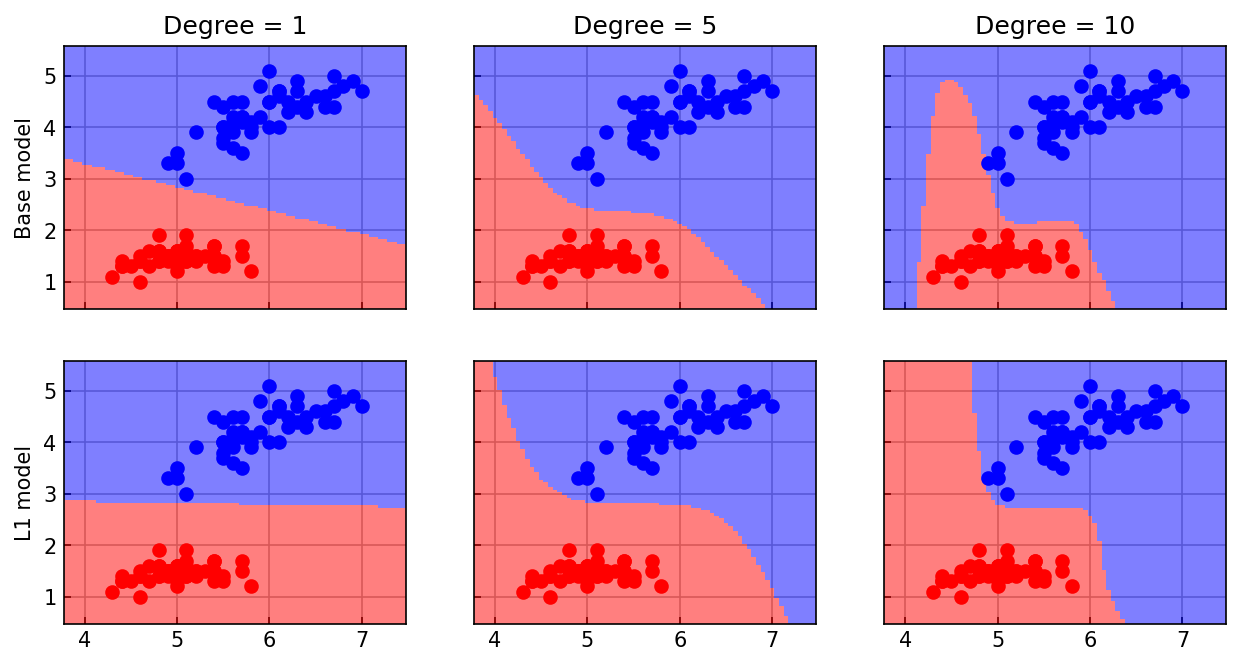

In [11]:
degrees = [1, 5, 10]
ax_db = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 5))[1]

for ii, degree in enumerate(degrees):
    base = LogisticRegressionPolynomial(degree=degree)
    base.fit(X, y_enc)
    plot_decision_boundary(ax_db[0, ii], X, y_enc, base)

    regd = L1LogisticRegression(degree=degree, reg_weight=0.1)
    regd.fit(X, y_enc)
    plot_decision_boundary(ax_db[1, ii], X, y_enc, regd)

    ax_db[0, ii].set_title(f'Degree = {degree}')
    
ax_db[0,0].set_ylabel('Base model')
ax_db[1,0].set_ylabel('L1 model')

Degree 10 augmented feature set contains 65 features


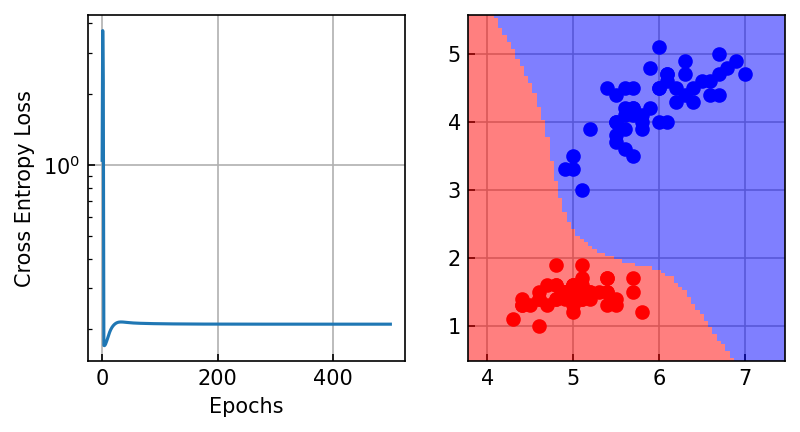

In [12]:
class L2LogisticRegression(LogisticRegressionPolynomial):
    def __init__(self, reg_weight=0.1, **kwargs):
        self.reg_weight = reg_weight
        super().__init__(**kwargs)

    def _fit_epoch(self, X, y):
        X_prep = self._preprocess(X)
        z_pred = self._pre_activation(X_prep)
        y_pred = self._activation(z_pred)
        diff = y - y_pred

        self.w_ += self.alpha * diff.dot(X_prep) / X.shape[0] - \
            self.alpha * self.reg_weight * self.w_
        self.b_ += self.alpha * diff.sum() / X.shape[0]

        loss = self._cross_entropy(y, y_pred)
        return loss

l2_model = L2LogisticRegression(degree=10, reg_weight=0.5)
l2_model.fit(X, y_enc)

fig, ax = plt.subplots(1, 2, figsize=(6,3))
ax[0].plot(l2_model.loss)
ax[0].set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='log');
plot_decision_boundary(ax[1], X, y_enc, l2_model)

Degree 1 augmented feature set contains 2 features
Degree 1 augmented feature set contains 2 features
Degree 5 augmented feature set contains 20 features
Degree 5 augmented feature set contains 20 features
Degree 10 augmented feature set contains 65 features
Degree 10 augmented feature set contains 65 features


Text(0, 0.5, 'L2 model')

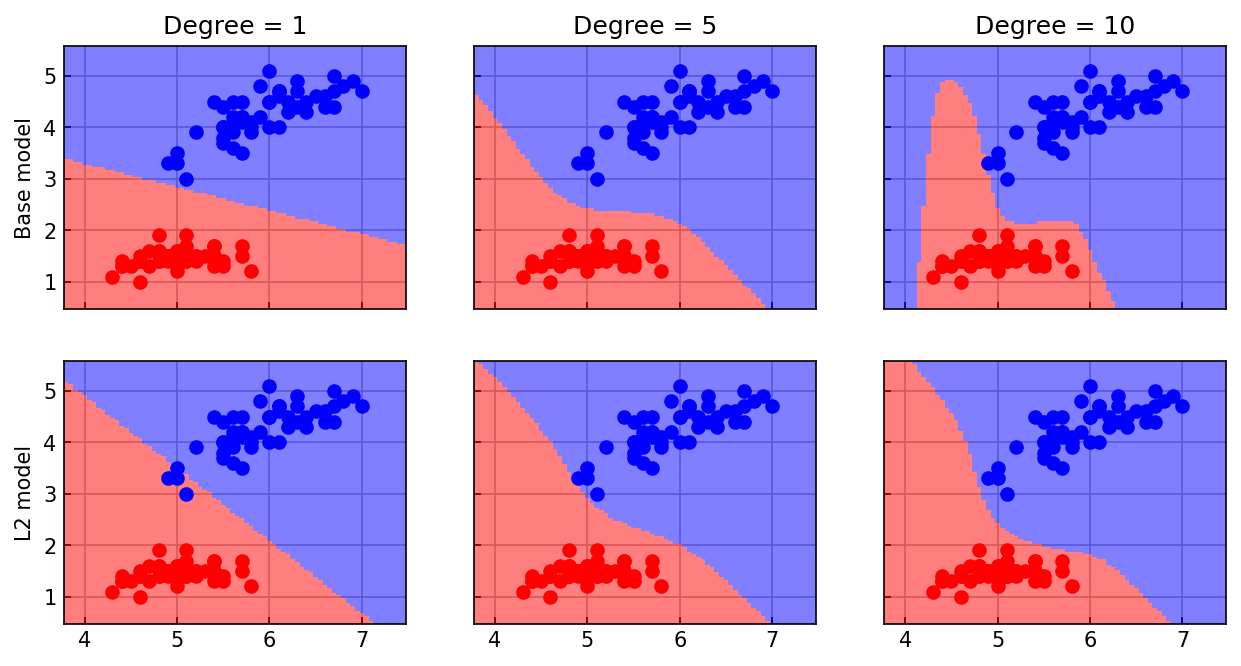

In [13]:
degrees = [1, 5, 10]
ax_db = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 5))[1]

for ii, degree in enumerate(degrees):
    base = LogisticRegressionPolynomial(degree=degree)
    base.fit(X, y_enc)
    plot_decision_boundary(ax_db[0, ii], X, y_enc, base)

    regd = L2LogisticRegression(degree=degree, reg_weight=0.5)
    regd.fit(X, y_enc)
    plot_decision_boundary(ax_db[1, ii], X, y_enc, regd)

    ax_db[0, ii].set_title(f'Degree = {degree}')
    
ax_db[0,0].set_ylabel('Base model')
ax_db[1,0].set_ylabel('L2 model')

Degree 10 augmented feature set contains 65 features


<Axes: xlabel='coef', ylabel='model'>

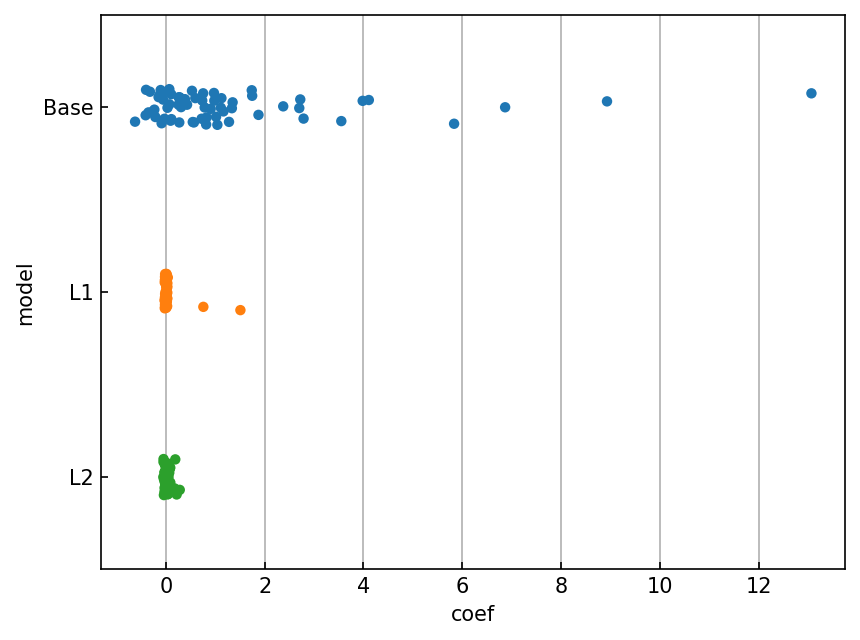

In [14]:
import seaborn as sns

# Get a base degree-10 model to compare coefficients
lr_model = LogisticRegressionPolynomial(degree=10, alpha=0.25, num_epochs=500)
lr_model.fit(X, y_enc)

# Plot coefficients to see effects of regularization
df = pd.concat([
    pd.DataFrame(data={'coef': lr_model.w_}).assign(model='Base'),
    pd.DataFrame(data={'coef': l1_model.w_}).assign(model='L1'),
    pd.DataFrame(data={'coef': l2_model.w_}).assign(model='L2'),
])
df.head

sns.stripplot(
    data=df,
    x = 'coef',
    y = 'model',
    hue = 'model'
)

## We could even try a nonlinear problem!

[Text(0.5, 0, '$x_0$'), Text(0, 0.5, '$x_1$'), None]

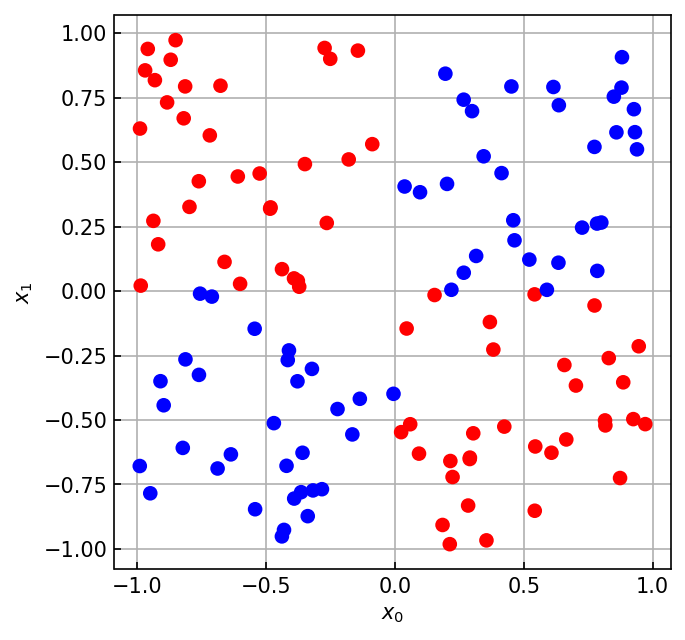

In [15]:
def make_xor_dataset(N=128, random_seed=42):
    np.random.seed(random_seed)
    X = 2 * np.random.uniform(size=(N, 2)) - 1
    y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0)
    y = np.where(y, 1, 0)
    return X, y

X_nl, y_nl = make_xor_dataset()

ax = plt.figure().gca()
ax.scatter(X_nl[:, 0], X_nl[:, 1], c=y_nl, cmap='bwr')
ax.set(xlabel='$x_0$', ylabel='$x_1$', aspect='equal')

Degree 3 augmented feature set contains 9 features


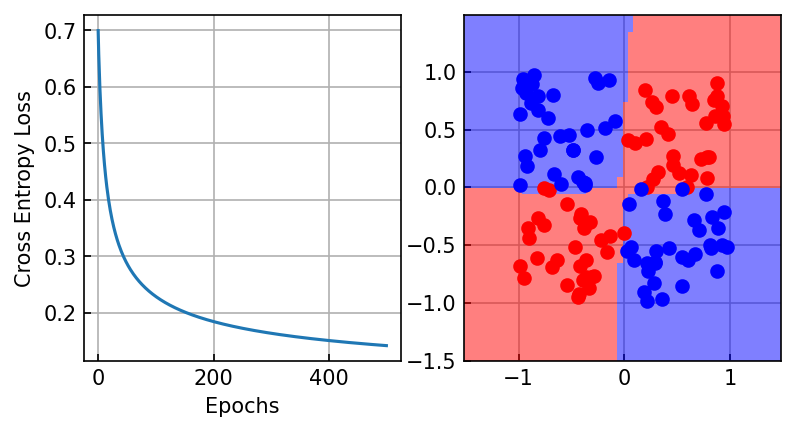

In [16]:
nl_model = LogisticRegressionPolynomial(degree=3)
nl_model.fit(X_nl, y_nl)

fig, ax = plt.subplots(1, 2, figsize=(6,3))
ax[0].plot(nl_model.loss)
ax[0].set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='linear');
plot_decision_boundary(ax[1], X_nl, y_nl, nl_model)

## Extension: Multi-class Logistic Regression

Fitting a dataset with X: (150, 2) and y: (150, 3)


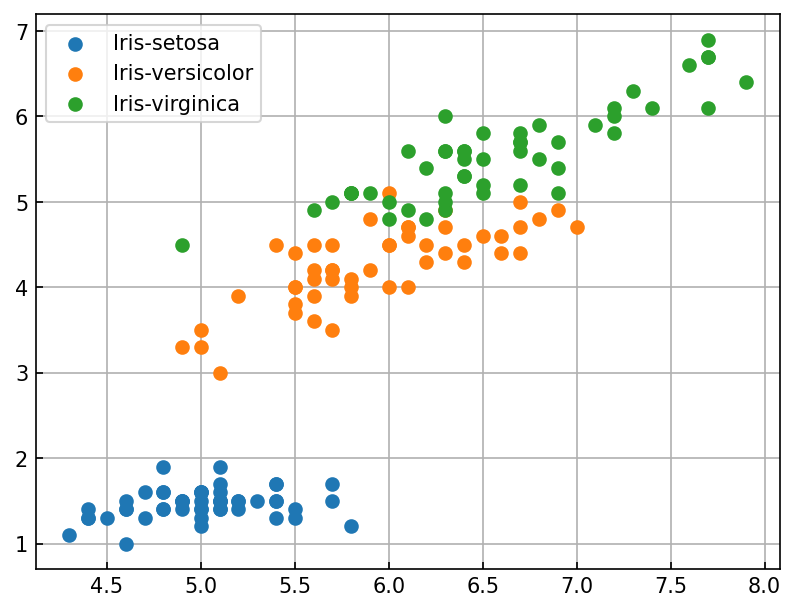

In [17]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data',
                 header=None, encoding='utf-8')

X = df.loc[:, [0, 2]].values
y = df.loc[:, 4].values

labels = np.unique(y)

y_onehot = np.zeros([y.shape[0], len(labels)], dtype=int)
for i, label in enumerate(labels):
    y_onehot[y == label, i] = 1

print(f"Fitting a dataset with X: {X.shape} and y: {y_onehot.shape}")

labels = np.unique(y)
ax = plt.figure().gca()
for label in labels:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=label)
ax.legend();

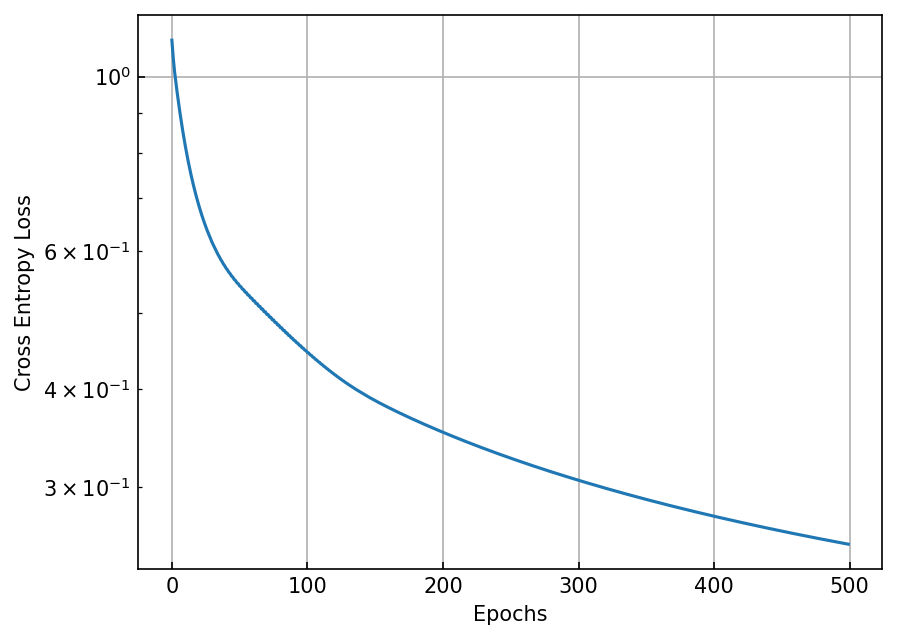

In [18]:
def multiclass_cross_entropy(y_true, y_pred, eps=1e-10):
    """ y_true is a one-hot encoded class label of shape [N, c]
        y_pred is a set of class probabilities of shape [N, c]
    """
    return -np.sum(y_true * np.log(y_pred + eps)) / y_true.shape[0]

class LogisticRegressionMulticlass:
    def __init__(self, alpha=0.1, num_epochs=500, random_seed=42):
        self.alpha = alpha
        self.num_epochs = num_epochs
        self.random_seed = 42

    def _pre_activation(self, X):
        return np.dot(X, self.w_) + self.b_

    def _activation(self, z):
        """ Softmax activation """
        zr = z - np.max(z, axis=1, keepdims=True)
        expz = np.exp(zr)
        return expz / np.sum(expz, axis=1, keepdims=True)

    def fit(self, X, y):
        """ X has shape [100, 2]
            y has shape [100, 3]
        """
        N, k = X.shape
        assert y.shape[0] == N
        _, c = y.shape

        np.random.seed(self.random_seed)
        # w_ is now a [k, c] matrix because we need to produce a 
        # separate output for each possible class
        self.w_ = np.random.normal(loc=0., scale=0.01, size=(k, c))
        # b_ is now a vector containing a separate bias for each class
        self.b_ = np.zeros(c)

        self.loss = []

        # iterate over epochs
        for epoch in range(self.num_epochs):
             loss = self._fit_epoch(X, y)
             self.loss.append(loss)

        return self
    def _fit_epoch(self, X, y):
        # Vectorize computation of preactivations and sigmoid
        z_pred = self._pre_activation(X) #[N, c]
        y_pred = self._activation(z_pred) #[N, c]
        diff = y - y_pred

        # [N, k], [N, c] -> [k, c] for weights
        self.w_ += self.alpha * np.einsum('Bi,Bj->ij', X, diff) / X.shape[0]
        # [N, c] -> [c,] for bias
        self.b_ += self.alpha * np.einsum('Bi->i', diff) / X.shape[0]
        
        loss = multiclass_cross_entropy(y, y_pred)
        return loss

    def predict(self, X):
        z = self._pre_activation(X)
        y_pred = self._activation(z)
        return np.argmax(y_pred, axis=1)

model_multiclass = LogisticRegressionMulticlass()
model_multiclass.fit(X, y_onehot)

ax = plt.figure().gca()
ax.plot(model_multiclass.loss)
ax.set(xlabel='Epochs', ylabel='Cross Entropy Loss', yscale='log');

[Text(0.5, 0, 'Sepal length [cm]'), Text(0, 0.5, 'Petal length [cm]')]

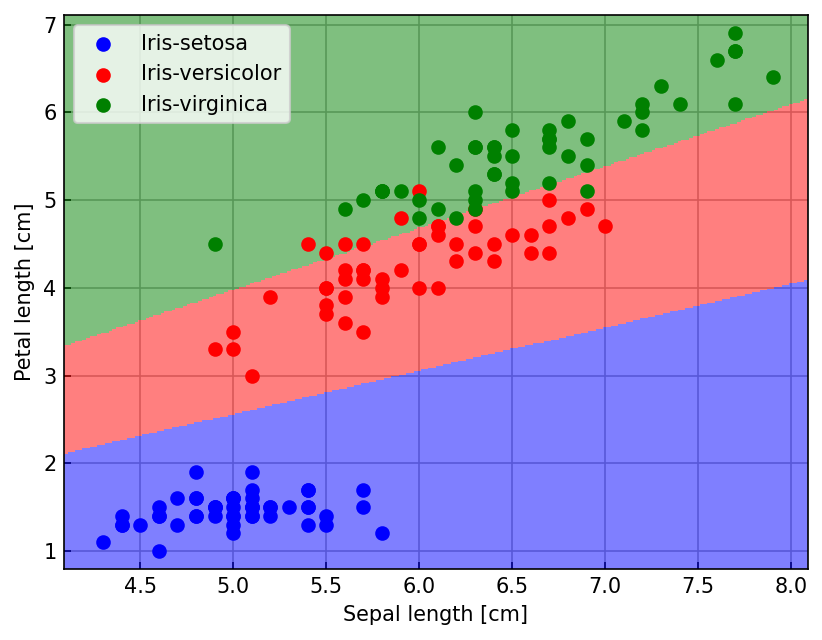

In [19]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.02, colors=['blue', 'red', 'green'], labels=None):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min()-10*d, X[:, 0].max()+10*d, d),
        np.arange(X[:, 1].min()-10*d, X[:, 1].max()+10*d, d),
    )
    y_model = model.predict(np.stack([x1.ravel(), x2.ravel()]).T)
    y_model = y_model.reshape(x1.shape)

    cmap = ListedColormap(colors)
    im=ax.pcolormesh(x1, x2, y_model, alpha=0.5, cmap=cmap)
    for label in range(y.shape[1]):
        mask = y[:, label] == 1
        ax.scatter(X[mask, 0], X[mask, 1], color=colors[label], label=labels[label] if labels is not None else None)
    if labels is not None:
        ax.legend()
    return ax

ax = plt.figure().gca()
plot_decision_boundary(ax, X, y_onehot, model_multiclass, labels=labels)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')